### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm
import catboost as cb

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GroupKFold



### Read files & submission file for template

In [2]:
X_train = pd.read_csv('../data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('../data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('../data/y_train.csv',index_col='ROW_ID')
y_train_clf = pd.DataFrame((y_train['target']>0).astype(int))
sample_submission = pd.read_csv('../submissions/sample_submission.csv',index_col='ROW_ID')

In [3]:
X_train.head(5)

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


In [4]:
print("Details in the ALLOCATION feature:")
print(X_train['ALLOCATION'].value_counts())

Details in the ALLOCATION feature:
ALLOCATION
ALLOCATION_42     2439
ALLOCATION_59     2439
ALLOCATION_239    2439
ALLOCATION_138    2439
ALLOCATION_137    2439
                  ... 
ALLOCATION_214    1431
ALLOCATION_205    1431
ALLOCATION_202    1431
ALLOCATION_14       19
ALLOCATION_46       19
Name: count, Length: 278, dtype: int64


### Features

In [5]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [6]:
X_train.fillna(0)
X_test.fillna(0)

for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    X_train[ f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    X_train[ f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    X_test[ f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(1)
    X_test[ f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')

# Hash frequent ALLOCATION values and flag rare ones in a dedicated column
hash_allocation = {v: i for i, v in enumerate(X_train['ALLOCATION'].value_counts().index)}


X_train['ALLOCATION'] = X_train['ALLOCATION'].map(hash_allocation).fillna(-1).astype(int)
X_test['ALLOCATION'] = X_test['ALLOCATION'].map(hash_allocation).fillna(-1).astype(int)

In [21]:
features = RET_features + TURNOVER_features + SIGNED_VOLUME_features + ['GROUP', 'ALLOCATION']
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'STD_PERF_{i}' for i in [20]]
features = features + [ f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]

print("Features used for the model:")
print(features)

Features used for the model:
['RET_1', 'RET_2', 'RET_3', 'RET_4', 'RET_5', 'RET_6', 'RET_7', 'RET_8', 'RET_9', 'RET_10', 'RET_11', 'RET_12', 'RET_13', 'RET_14', 'RET_15', 'RET_16', 'RET_17', 'RET_18', 'RET_19', 'RET_20', 'MEDIAN_DAILY_TURNOVER', 'SIGNED_VOLUME_1', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_20', 'GROUP', 'ALLOCATION', 'AVERAGE_PERF_3', 'AVERAGE_PERF_5', 'AVERAGE_PERF_10', 'AVERAGE_PERF_15', 'AVERAGE_PERF_20', 'ALLOCATIONS_AVERAGE_PERF_3', 'ALLOCATIONS_AVERAGE_PERF_5', 'ALLOCATIONS_AVERAGE_PERF_10', 'ALLOCATIONS_AVERAGE_PERF_15', 'ALLOCATIONS_AVERAGE_PERF_20', 'STD_PERF_20', 'ALLOCATIONS_STD_PERF_20']


### Fitting a catboost using cross validation

In [11]:
features_lgbm = features

In [12]:

train_dates = X_train['TS'].unique()
test_dates = X_test['TS'].unique()

n_splits = 8
scores_cb = []
models_cb = []
 
splits = KFold(n_splits=n_splits, random_state=0,
               shuffle=True,).split(train_dates)

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids,[x for x in features_lgbm ]] 
    y_local_train = y_train_clf.loc[local_train_ids,'target']
    
    X_local_test = X_train.loc[local_test_ids,[x for x in features_lgbm ]] 
    y_local_test = y_train_clf.loc[local_test_ids,'target']
    
    X_local_train = X_local_train
    X_local_test = X_local_test
    train_data = cb.Pool(
        X_local_train,
        label=y_local_train,
        cat_features=['GROUP', 'ALLOCATION']
    )
    valid_data = cb.Pool(
        X_local_test,
        label=y_local_test,
        cat_features=['GROUP', 'ALLOCATION']
    )

    model_cb = cb.CatBoostClassifier(n_estimators=500,
                                    depth=10,
                                    learning_rate=1e-2,
                                    random_seed=42,
                                    thread_count=-1, 
                                    verbose=True)

    model_cb.fit(train_data, eval_set=valid_data, early_stopping_rounds=50, use_best_model=True)
    y_local_pred = model_cb.predict(X_local_test).astype(int).ravel()
    
    
    models_cb.append(model_cb)
    score = accuracy_score((y_local_test>0).astype(int),
                (y_local_pred>0).astype(int))
    scores_cb.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores_cb)*100
std = np.std(scores_cb)*100

u = (mean + std)
l = (mean - std)

print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')

0:	learn: 0.6930637	test: 0.6931101	best: 0.6931101 (0)	total: 518ms	remaining: 4m 18s
1:	learn: 0.6929811	test: 0.6930633	best: 0.6930633 (1)	total: 998ms	remaining: 4m 8s
2:	learn: 0.6929269	test: 0.6930259	best: 0.6930259 (2)	total: 1.43s	remaining: 3m 57s
3:	learn: 0.6928370	test: 0.6929832	best: 0.6929832 (3)	total: 1.9s	remaining: 3m 55s
4:	learn: 0.6927658	test: 0.6929442	best: 0.6929442 (4)	total: 2.37s	remaining: 3m 54s
5:	learn: 0.6927022	test: 0.6929104	best: 0.6929104 (5)	total: 2.82s	remaining: 3m 51s
6:	learn: 0.6926448	test: 0.6928851	best: 0.6928851 (6)	total: 3.28s	remaining: 3m 50s
7:	learn: 0.6925786	test: 0.6928591	best: 0.6928591 (7)	total: 3.76s	remaining: 3m 51s
8:	learn: 0.6925023	test: 0.6928306	best: 0.6928306 (8)	total: 4.22s	remaining: 3m 50s
9:	learn: 0.6924151	test: 0.6928131	best: 0.6928131 (9)	total: 4.71s	remaining: 3m 51s
10:	learn: 0.6923517	test: 0.6927787	best: 0.6927787 (10)	total: 5.18s	remaining: 3m 50s
11:	learn: 0.6922883	test: 0.6927497	best: 

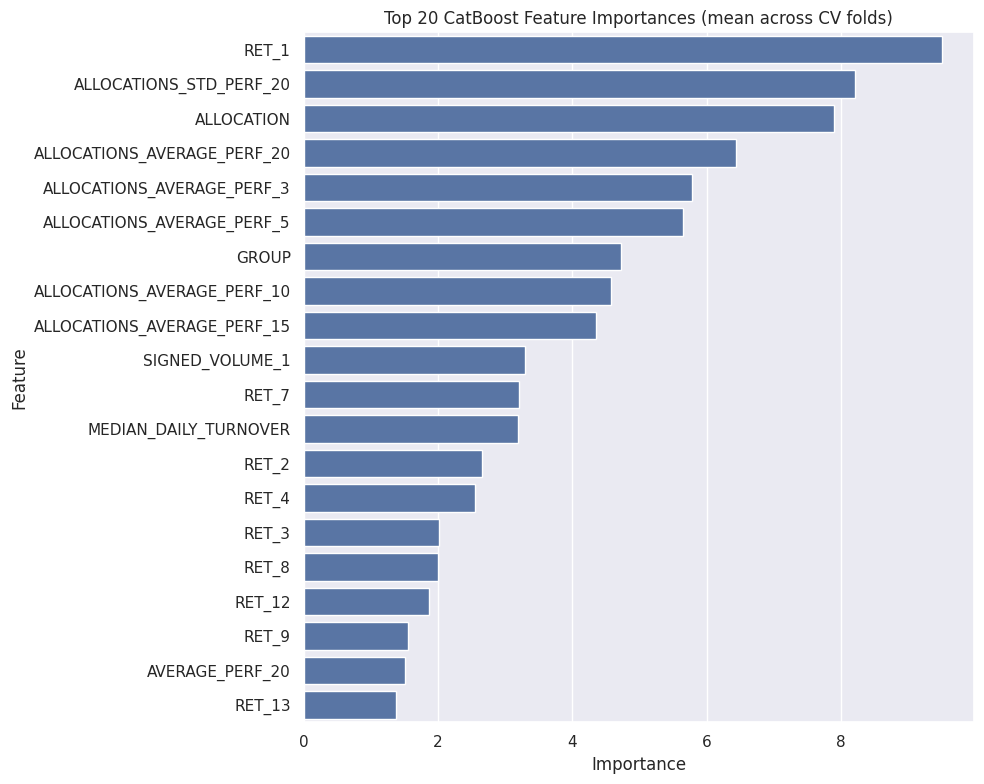

In [13]:
feature_importances = pd.DataFrame(
	[model_cb.get_feature_importance(type='FeatureImportance') for model_cb in models_cb],
	columns=features_lgbm
)

top_features = feature_importances.mean(0).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, orient='h')
plt.title('Top 20 CatBoost Feature Importances (mean across CV folds)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

### Taking the most sure model

In [ ]:
preds_list = []
for model_cb in models_cb:
    preds = model_cb.predict_proba(X_test[features_lgbm])[:, 1]
    preds_list.append(preds)
preds_array = np.array(preds_list)

preds_final = np.take_along_axis(
    preds_array,
    np.argmax(np.abs(preds_array - 0.5), axis=0)[None, :],
    axis=0
).ravel()
pd.DataFrame(preds_final>0.5, index=X_test.index, columns=['target']).to_csv('../submissions/cat_boost_submission.csv')

### Produce a solution blending the catboost models (weight by probability)

In [ ]:
preds = np.zeros(X_test.shape[0])
for model_cb in models_cb:
    preds += model_cb.predict_proba(X_test[features_lgbm])[:,1]

preds /= len(models_cb)
preds = pd.DataFrame(preds,
                    index=sample_submission.index,
                    columns=['target']
)
preds.head()

,target
ROW_ID,
527073,0.477567
527074,0.504195
527075,0.467639
527076,0.477473
527077,0.474685


In [ ]:
(preds>0.5).astype(int).to_csv('../submissions/preds_catboost.csv')
print("Predictions saved to ../submissions/preds_catboost.csv")

Predictions saved to ../submissions/preds_catboost.csv


### Retrain a solution on the full training data and predict on the test set.

In [18]:
train_data_full = cb.Pool(
    X_train[features_lgbm],
    label=y_train_clf['target'],
    cat_features=['GROUP', 'ALLOCATION']
 )

model_cb_full = cb.CatBoostClassifier(
    n_estimators=300,
    depth=10,
    learning_rate=1e-2,
    random_seed=42,
    thread_count=-1,
    verbose=True
)

model_cb_full.fit(train_data_full)

preds_cb = pd.DataFrame(
    model_cb_full.predict_proba(X_test[features_lgbm])[:, 1],
    index=sample_submission.index,
    columns=['target']
 )

preds_cb.head()

0:	learn: 0.6930685	total: 633ms	remaining: 3m 9s
1:	learn: 0.6930025	total: 1.18s	remaining: 2m 55s
2:	learn: 0.6929318	total: 1.75s	remaining: 2m 53s
3:	learn: 0.6928564	total: 2.33s	remaining: 2m 52s
4:	learn: 0.6928039	total: 2.87s	remaining: 2m 49s
5:	learn: 0.6927421	total: 3.37s	remaining: 2m 45s
6:	learn: 0.6926689	total: 3.9s	remaining: 2m 43s
7:	learn: 0.6926163	total: 4.34s	remaining: 2m 38s
8:	learn: 0.6925529	total: 4.83s	remaining: 2m 36s
9:	learn: 0.6924864	total: 5.4s	remaining: 2m 36s
10:	learn: 0.6924160	total: 5.98s	remaining: 2m 37s
11:	learn: 0.6923726	total: 6.45s	remaining: 2m 34s
12:	learn: 0.6923049	total: 7s	remaining: 2m 34s
13:	learn: 0.6922426	total: 7.5s	remaining: 2m 33s
14:	learn: 0.6921735	total: 8.03s	remaining: 2m 32s
15:	learn: 0.6921071	total: 8.63s	remaining: 2m 33s
16:	learn: 0.6920630	total: 9.1s	remaining: 2m 31s
17:	learn: 0.6920034	total: 9.61s	remaining: 2m 30s
18:	learn: 0.6919181	total: 10.1s	remaining: 2m 29s
19:	learn: 0.6918582	total: 10

,target
ROW_ID,
527073,0.468020
527074,0.497494
527075,0.466799
527076,0.476961
527077,0.479232


In [19]:
(preds_cb > 0.5).astype(int).to_csv('../submissions/preds_catboost.csv')
print("Predictions saved to ../submissions/preds_catboost.csv")

Predictions saved to ../submissions/preds_catboost.csv


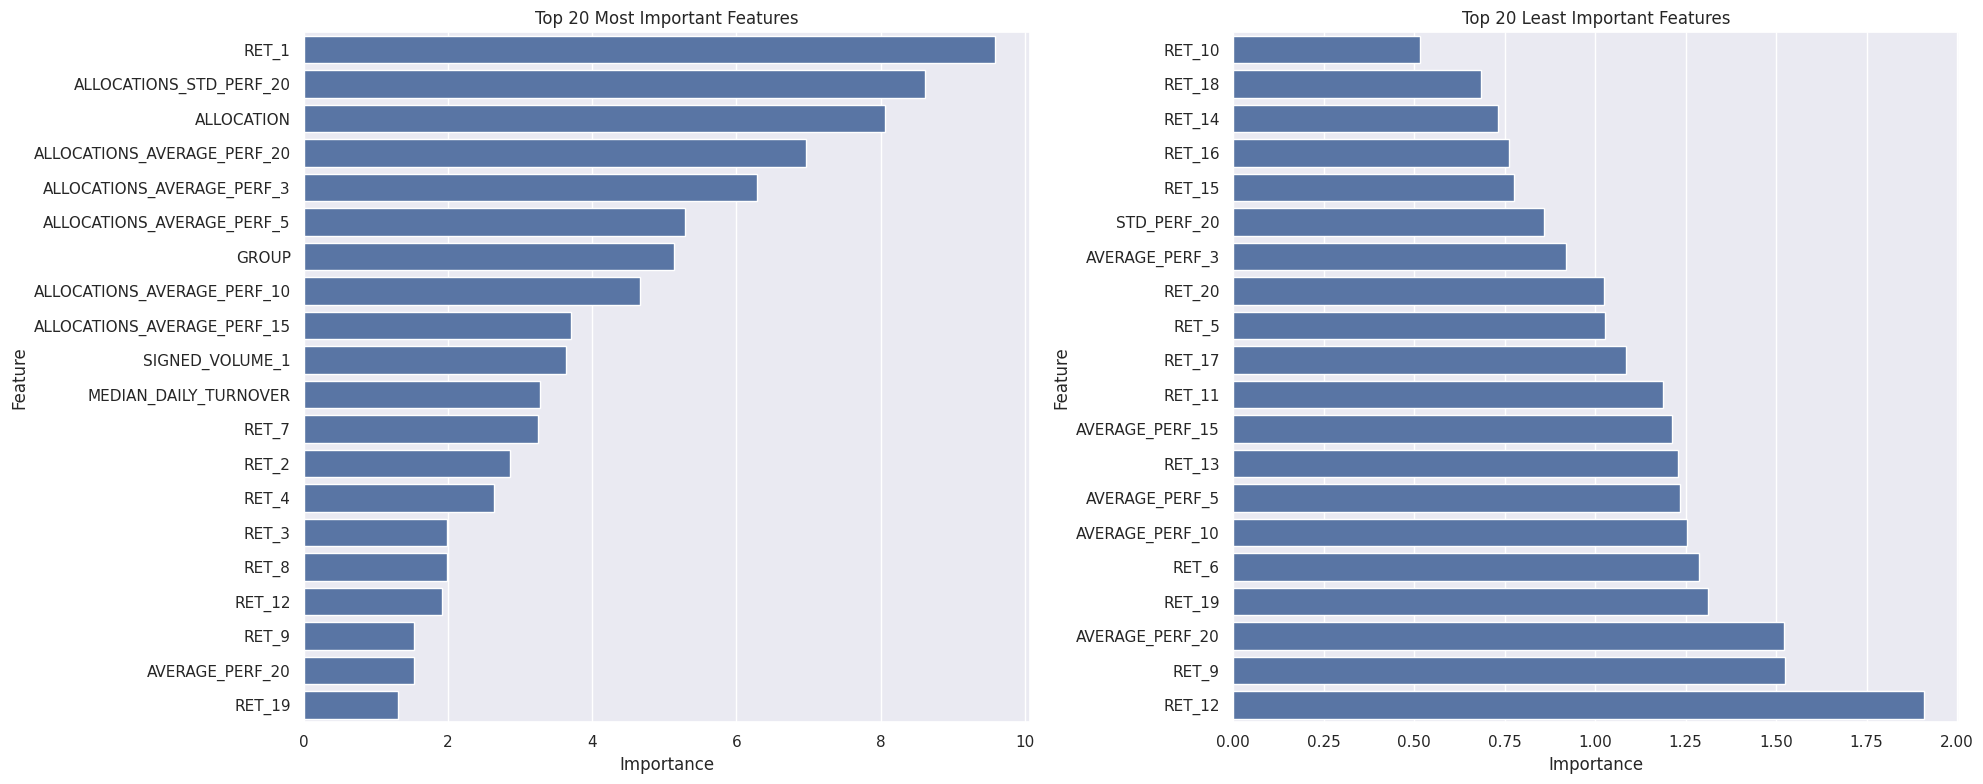

In [20]:
feature_importances = pd.Series(
	model_cb_full.get_feature_importance(type='FeatureImportance'),
	index=features_lgbm
)

top_features = feature_importances.sort_values(ascending=False).head(20)
bottom_features = feature_importances.sort_values(ascending=True).head(20)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x=top_features.values, y=top_features.index, orient='h', ax=axes[0])
axes[0].set_title('Top 20 Most Important Features')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

sns.barplot(x=bottom_features.values, y=bottom_features.index, orient='h', ax=axes[1])
axes[1].set_title('Top 20 Least Important Features')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()